# Final Results Analysis — EEEM068 LSA Melanoma Classification

All core models and scientific artifacts are frozen. This notebook performs no training; it reads the J1 authoritative evidence bundle for analysis and manual review. Fold 0 is the fixed patient-aware validation fold. AP denotes Average Precision.

In [1]:
from pathlib import Path
import hashlib
import json
import subprocess

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from PIL import Image as PILImage

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "outputs" / "final" / "tables").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the repository root")

ROOT = find_repo_root(Path.cwd().resolve())
TABLE_DIR = ROOT / "outputs" / "final" / "tables"
MANIFEST_DIR = ROOT / "outputs" / "final" / "manifests"

table_names = ('dataset_summary', 'main_model_results', 'deep_model_protocol', 'hyperparameter_selection', 'training_summary', 'B0_M1_architecture_comparison', 'M1_M2_metadata_ablation', 'threshold_summary', 'bootstrap_summary', 'subgroup_summary', 'failure_summary', 'integrity_summary')
tables = {name: pd.read_csv(TABLE_DIR / f"{name}.csv") for name in table_names}

def read_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))

j1_complete = read_json(MANIFEST_DIR / "J1_COMPLETE.json")
j1_table_manifest = read_json(MANIFEST_DIR / "J1B_tables_manifest.json")
authoritative_sources = read_json(MANIFEST_DIR / "authoritative_sources.json")
comparison_boundaries = read_json(MANIFEST_DIR / "comparison_boundaries.json")
hyperparameter_strategy = read_json(MANIFEST_DIR / "hyperparameter_strategy.json")
j1_handoff = (ROOT / "outputs" / "final" / "J1_HANDOFF.md").read_text(encoding="utf-8")

boundary_names = {item["comparison"] for item in comparison_boundaries["boundaries"]}
required_boundaries = {"H0_to_H1", "H0_H1_to_B0", "B0_to_M1", "M1_to_M2"}
source_categories = {item["claim_category"] for item in authoritative_sources["sources"]}
assert required_boundaries.issubset(boundary_names)
assert {"precision_recall_metric_definition", "validation_set_definition"}.issubset(source_categories)
assert "Average Precision (AP)" in j1_handoff
assert "fixed patient-aware validation fold" in j1_handoff

git_head = subprocess.run(
    ["git", "rev-parse", "HEAD"],
    cwd=ROOT,
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()

assert j1_complete["status"] == "COMPLETE"
display(pd.DataFrame({
    "Item": ["Repository", "Current Git HEAD", "J1 status", "Tables loaded"],
    "Value": [ROOT.name, git_head, j1_complete["status"], len(tables)],
}))

,Item,Value
0,Repository,EEEM068_LSA_Melanoma
1,Current Git HEAD,5f16180a6ede376cd2608f7da4a41a1b9d4e06c1
2,J1 status,COMPLETE
3,Tables loaded,12


## 1. Dataset and validation summary

Evidence: `dataset_summary.csv` and `integrity_summary.csv`. The compact view reports the frozen dataset, fixed Fold-0 split, patient separation, and exact-content audit.

In [2]:
dataset = tables["dataset_summary"].iloc[0]
integrity = tables["integrity_summary"].iloc[0]

dataset_view = pd.DataFrame({
    "Measure": [
        "Total images", "Benign", "Melanoma", "Melanoma prevalence", "Patients",
        "Training N", "Validation N", "Training positives", "Validation positives",
        "Patient overlap", "Exact duplicate groups", "Cross-split exact duplicates",
    ],
    "Value": [
        int(dataset.total_images), int(dataset.benign_images), int(dataset.melanoma_images),
        f"{float(dataset.melanoma_prevalence):.3%}", int(dataset.unique_patients),
        int(dataset.train_images), int(dataset.validation_images), int(dataset.train_melanoma),
        int(dataset.validation_melanoma), int(dataset.patient_overlap),
        int(dataset.exact_duplicate_groups), int(dataset.cross_split_exact_duplicates),
    ],
})
display(dataset_view)

,Measure,Value
0,Total images,33126
1,Benign,32542
2,Melanoma,584
3,Melanoma prevalence,1.763%
4,Patients,2056
5,Training N,26499
6,Validation N,6627
7,Training positives,467
8,Validation positives,117
9,Patient overlap,0


The dataset is severely class-imbalanced. The split is patient-aware, and the exact-content audit found no cross-split duplicate leakage.

## 2. Main model hierarchy

Evidence: `main_model_results.csv`. Values are rounded only in the display below; the loaded table retains full precision.

In [3]:
main_results = tables["main_model_results"].copy()
expected_models = ["H0", "H1", "B0", "M1", "M2"]
assert main_results["model_id"].tolist() == expected_models

hierarchy = main_results[[
    "model_id", "input_representation", "metadata_used", "imbalance_strategy",
    "roc_auc", "average_precision", "sensitivity", "specificity", "f1", "accuracy",
]].rename(columns={
    "model_id": "Model", "input_representation": "Representation",
    "metadata_used": "Metadata", "imbalance_strategy": "Imbalance strategy",
    "roc_auc": "ROC-AUC", "average_precision": "AP",
    "sensitivity": "Sensitivity", "specificity": "Specificity",
    "f1": "F1", "accuracy": "Accuracy",
})
display(hierarchy.round({
    "ROC-AUC": 4, "AP": 4, "Sensitivity": 4,
    "Specificity": 4, "F1": 4, "Accuracy": 4,
}))

,Model,Representation,Metadata,Imbalance strategy,ROC-AUC,AP,Sensitivity,Specificity,F1,Accuracy
0,H0,64x64 grayscale flattened pixels,False,none,0.6570,0.0386,0.0085,0.9985,0.0156,0.9810
1,H1,64x64 grayscale flattened pixels,False,balanced class weights,0.6244,0.0363,0.1453,0.9515,0.0756,0.9372
2,B0,224x224 RGB images,False,training-derived weighted BCE,0.8643,0.1193,0.7949,0.7676,0.1080,0.7681
3,M1,224x224 RGB images,False,training-derived weighted BCE,0.9008,0.1694,0.9744,0.6276,0.0859,0.6338
4,M2,"224x224 RGB images + age, sex, anatomical site",True,training-derived weighted BCE,0.8974,0.1653,0.8974,0.7359,0.1082,0.7388


Interpretation boundaries:

- **H0 to H1:** historical Logistic Regression weighting comparison.
- **H0/H1 to B0:** system-level historical progression, not an isolated architecture effect.
- **B0 to M1:** matched training and evaluation protocol architecture-family comparison.
- **M1 to M2:** metadata-fusion system ablation; individual metadata fields are not assigned causal effects.

## 3. H0 to H1 imbalance effect

Evidence: threshold-0.5 metrics and confusion counts in `main_model_results.csv`.

In [4]:
imbalance_metrics = [
    "accuracy", "balanced_accuracy", "precision", "sensitivity", "specificity",
    "f1", "roc_auc", "average_precision", "tn", "fp", "fn", "tp",
]
h0_h1 = (
    main_results.loc[main_results.model_id.isin(["H0", "H1"]), ["model_id", *imbalance_metrics]]
    .set_index("model_id")
    .T
    .rename(index={"roc_auc": "ROC-AUC", "average_precision": "AP"})
)
display(h0_h1.round(4))

model_id,H0,H1
accuracy,0.9810,0.9372
balanced_accuracy,0.5035,0.5484
precision,0.0909,0.0511
sensitivity,0.0085,0.1453
specificity,0.9985,0.9515
f1,0.0156,0.0756
ROC-AUC,0.6570,0.6244
AP,0.0386,0.0363
tn,6500.0000,6194.0000
fp,10.0000,316.0000


H0's high accuracy is majority-class dominated. H1 weighting increases melanoma sensitivity, while ranking metrics do not necessarily improve. This comparison shows why accuracy alone is misleading under severe imbalance; it does not isolate a deep-architecture effect.

## 4. B0 to M1 controlled architecture comparison

Evidence: `B0_M1_architecture_comparison.csv` and `deep_model_protocol.csv`.

In [5]:
architecture_comparison = tables["B0_M1_architecture_comparison"]
display(
    architecture_comparison[["metric", "B0", "M1", "M1_minus_B0"]]
    .rename(columns={"M1_minus_B0": "Delta (M1 - B0)"})
    .round(4)
)

protocol = tables["deep_model_protocol"].set_index("model_id")
protocol_items = [
    ("Split", "Fixed Fold-0 validation"),
    ("Image size", "image_size"), ("Loss", "loss"), ("pos_weight", "pos_weight"),
    ("Optimizer", "optimizer"), ("Learning rate", "learning_rate"),
    ("Weight decay", "weight_decay"), ("Scheduler", "scheduler"), ("AMP", "amp"),
    ("Maximum epochs", "max_epochs"), ("Patience", "patience"),
    ("Checkpoint metric", "checkpoint_metric"), ("Primary threshold", "primary_threshold"),
    ("Parameter count", "parameter_count"), ("Actual epochs", "actual_epochs"),
]
protocol_view = []
for label, source in protocol_items:
    if label == "Split":
        b0_value = m1_value = source
    else:
        b0_value, m1_value = protocol.loc["B0", source], protocol.loc["M1", source]
    protocol_view.append({"Protocol item": label, "B0": b0_value, "M1": m1_value})
display(pd.DataFrame(protocol_view))

,metric,B0,M1,Delta (M1 - B0)
0,roc_auc,0.8643,0.9008,0.0366
1,average_precision,0.1193,0.1694,0.0501
2,accuracy,0.7681,0.6338,-0.1343
3,balanced_accuracy,0.7812,0.8010,0.0198
4,precision,0.0579,0.0449,-0.0130
5,sensitivity,0.7949,0.9744,0.1795
6,specificity,0.7676,0.6276,-0.1399
7,f1,0.1080,0.0859,-0.0221
8,tn,4997.0000,4086.0000,-911.0000
9,fp,1513.0000,2424.0000,911.0000


,Protocol item,B0,M1
0,Split,Fixed Fold-0 validation,Fixed Fold-0 validation
1,Image size,224,224
2,Loss,weighted_bce,weighted_bce
3,pos_weight,55.743041,55.743041
4,Optimizer,adamw,adamw
5,Learning rate,0.0001,0.0001
6,Weight decay,0.0001,0.0001
7,Scheduler,none,none
8,AMP,True,True
9,Maximum epochs,10,10


M1 improved the observed ROC-AUC, AP, and sensitivity, while specificity decreased at threshold 0.5. Under the documented matched external protocol, architecture family is the main externally controlled change; the difference cannot be assigned to one ConvNeXt mechanism.

## 5. M1 to M2 metadata ablation

Evidence: `M1_M2_metadata_ablation.csv` and `deep_model_protocol.csv`.

In [6]:
metadata_ablation = tables["M1_M2_metadata_ablation"]
display(
    metadata_ablation[["metric", "M1", "M2", "M2_minus_M1"]]
    .rename(columns={"M2_minus_M1": "Delta (M2 - M1)"})
    .round(4)
)

ablation_protocol = pd.DataFrame({
    "Measure": ["Parameters", "Parameter difference", "Actual epochs", "Best epoch", "Duration (s)"],
    "M1": [
        int(protocol.loc["M1", "parameter_count"]), 0,
        int(protocol.loc["M1", "actual_epochs"]), int(protocol.loc["M1", "best_epoch"]),
        float(protocol.loc["M1", "duration_seconds"]),
    ],
    "M2": [
        int(protocol.loc["M2", "parameter_count"]),
        int(protocol.loc["M2", "parameter_count"] - protocol.loc["M1", "parameter_count"]),
        int(protocol.loc["M2", "actual_epochs"]), int(protocol.loc["M2", "best_epoch"]),
        float(protocol.loc["M2", "duration_seconds"]),
    ],
})
display(ablation_protocol.round(3))

,metric,M1,M2,Delta (M2 - M1)
0,roc_auc,0.9008,0.8974,-0.0034
1,average_precision,0.1694,0.1653,-0.0041
2,accuracy,0.6338,0.7388,0.1050
3,balanced_accuracy,0.8010,0.8167,0.0157
4,precision,0.0449,0.0576,0.0126
5,sensitivity,0.9744,0.8974,-0.0769
6,specificity,0.6276,0.7359,0.1083
7,f1,0.0859,0.1082,0.0223
8,tn,4086.0000,4791.0000,705.0000
9,fp,2424.0000,1719.0000,-705.0000


,Measure,M1,M2
0,Parameters,2.782090e+07,2.782131e+07
1,Parameter difference,0.000000e+00,4.160000e+02
2,Actual epochs,7.000000e+00,1.000000e+01
3,Best epoch,4.000000e+00,8.000000e+00
4,Duration (s),7.674980e+02,1.080503e+03


Observed ROC-AUC and AP changed only slightly. At threshold 0.5, M2 increased specificity and reduced false positives, but reduced sensitivity and increased false negatives. Metadata did not provide a clear ranking advantage on this fold. Per-sample M1/M2 differences are descriptive model disagreements, not causal metadata effects.

## 6. Training behaviour

Evidence: frozen epoch records in `training_summary.csv`. The checkpoint marker denotes the maximum validation ROC-AUC epoch; no training ranking metric is inferred.

,Model,Best ROC-AUC epoch,Train loss,Validation loss,Validation ROC-AUC,Validation AP
3,B0,4,0.8660,1.0283,0.8643,0.1193
10,M1,4,0.8553,0.8010,0.9008,0.1694
21,M2,8,0.7937,0.8301,0.8974,0.1653


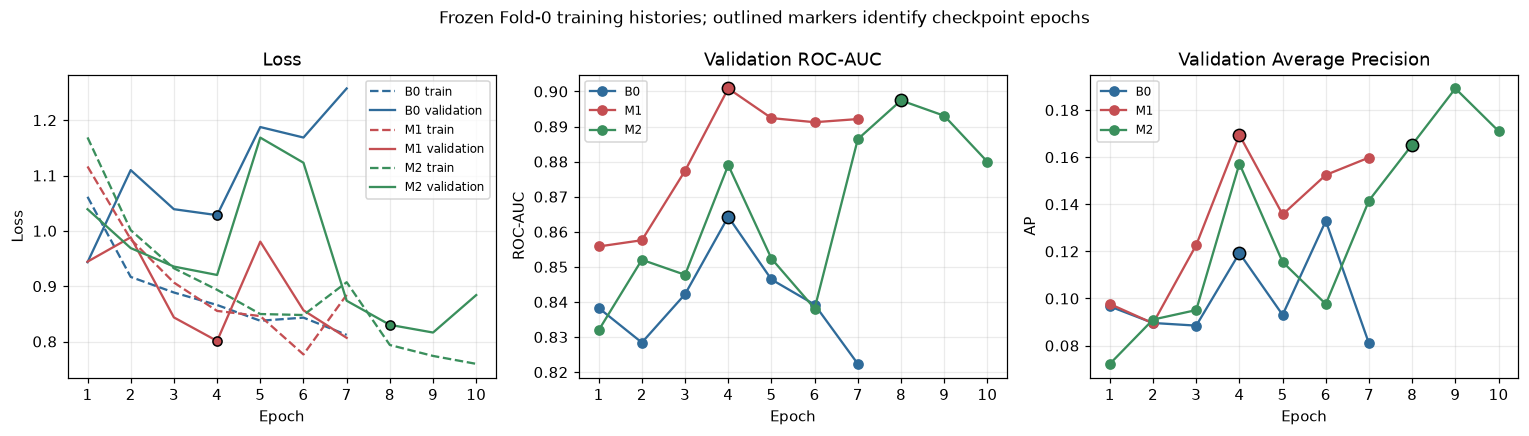

In [7]:
training = tables["training_summary"].copy()
best_mask = training["is_best_roc_auc_epoch"].astype(str).str.lower().eq("true")
best_rows = training.loc[best_mask, [
    "model_id", "epoch", "train_loss", "val_loss", "val_roc_auc", "val_average_precision",
]]
display(best_rows.rename(columns={
    "model_id": "Model", "epoch": "Best ROC-AUC epoch", "train_loss": "Train loss",
    "val_loss": "Validation loss", "val_roc_auc": "Validation ROC-AUC",
    "val_average_precision": "Validation AP",
}).round(4))

colors = {"B0": "#2f6b9a", "M1": "#c44e52", "M2": "#3a8f5c"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for model_id in ["B0", "M1", "M2"]:
    model_history = training.loc[training.model_id.eq(model_id)].sort_values("epoch")
    best = model_history.loc[
        model_history["is_best_roc_auc_epoch"].astype(str).str.lower().eq("true")
    ].iloc[0]
    color = colors[model_id]
    axes[0].plot(model_history.epoch, model_history.train_loss, "--", color=color, label=f"{model_id} train")
    axes[0].plot(model_history.epoch, model_history.val_loss, "-", color=color, label=f"{model_id} validation")
    axes[0].scatter(best.epoch, best.val_loss, color=color, edgecolor="black", zorder=3)
    axes[1].plot(model_history.epoch, model_history.val_roc_auc, color=color, marker="o", label=model_id)
    axes[1].scatter(best.epoch, best.val_roc_auc, color=color, edgecolor="black", s=65, zorder=3)
    axes[2].plot(model_history.epoch, model_history.val_average_precision, color=color, marker="o", label=model_id)
    axes[2].scatter(best.epoch, best.val_average_precision, color=color, edgecolor="black", s=65, zorder=3)

axes[0].set(title="Loss", xlabel="Epoch", ylabel="Loss")
axes[1].set(title="Validation ROC-AUC", xlabel="Epoch", ylabel="ROC-AUC")
axes[2].set(title="Validation Average Precision", xlabel="Epoch", ylabel="AP")
for axis in axes:
    axis.legend(fontsize=8)
    axis.set_xticks(sorted(training.epoch.unique()))
fig.suptitle("Frozen Fold-0 training histories; outlined markers identify checkpoint epochs", fontsize=11)
fig.tight_layout()
plt.show()

B0 and M1 reached their best validation ROC-AUC at epoch 4; M2 reached it at epoch 8. B0 and M1 show lower ROC-AUC after the checkpoint epoch. M2 also varies after epoch 8, with AP peaking one epoch later than the ROC-AUC-selected checkpoint.

## 7. Hyperparameter selection

Evidence: `hyperparameter_selection.csv` and `hyperparameter_strategy.json`. This section documents experimental control and its validation-design boundary.

In [8]:
hyperparameters = tables["hyperparameter_selection"][[
    "parameter", "B0_value", "M1_value", "M2_value", "selection_category", "systematically_tuned",
]].rename(columns={
    "parameter": "Parameter", "B0_value": "B0", "M1_value": "M1", "M2_value": "M2",
    "selection_category": "Selection category", "systematically_tuned": "Systematically tuned?",
})
display(hyperparameters)
display(pd.DataFrame({
    "Evidence statement": [
        hyperparameter_strategy["systematic_search_statement"],
        hyperparameter_strategy["matching_strategy"],
        hyperparameter_strategy["effective_duration_selection"],
        hyperparameter_strategy["threshold_strategy"],
        hyperparameter_strategy["stronger_future_design"],
    ]
}))

,Parameter,B0,M1,M2,Selection category,Systematically tuned?
0,image_size,224,224,224,predeclared_shared,NO
1,batch_size,32,32,32,predeclared_shared,NO
2,optimizer,adamw,adamw,adamw,predeclared_shared,NO
3,learning_rate,0.0001,0.0001,0.0001,predeclared_shared,NO
4,weight_decay,0.0001,0.0001,0.0001,predeclared_shared,NO
5,loss,weighted_bce,weighted_bce,weighted_bce,predeclared_shared,NO
6,pos_weight,55.74304068522484,55.74304068522484,55.74304068522484,data_derived,NO
7,scheduler,none,none,none,predeclared_shared,NO
8,max_epochs,10,10,10,predeclared_shared,NO
9,early_stopping_patience,3,3,3,predeclared_shared,NO


,Evidence statement
0,"A systematic grid, random, or Bayesian hyperpa..."
1,Deep-model settings were deliberately matched ...
2,Early stopping and maximum validation ROC-AUC ...
3,Threshold 0.5 is the predeclared common compar...
4,A stronger tuning design would require a separ...


No systematic grid search, random search, or Bayesian tuning was performed. Common deep-model settings were deliberately matched; `pos_weight` was derived from training class counts. Early stopping and validation ROC-AUC checkpointing selected effective duration. The threshold grid is post-hoc behavioural analysis. A stronger future tuning design would use patient-grouped inner validation or nested cross-validation.

## 8. Threshold behaviour

Evidence: the fixed 0.1 to 0.9 grid in `threshold_summary.csv`. Threshold 0.5 is the predeclared common primary threshold; the grid is descriptive and post-hoc.

M1                                        M2                              
          sensitivity specificity precision      f1 sensitivity specificity precision      f1
threshold                                                                                    
0.1            1.0000      0.4751    0.0331  0.0641      0.9573      0.5455    0.0365  0.0703
0.2            1.0000      0.5031    0.0349  0.0675      0.9573      0.5949    0.0407  0.0782
0.3            1.0000      0.5356    0.0373  0.0718      0.9316      0.6401    0.0445  0.0849
0.4            0.9915      0.5739    0.0401  0.0772      0.9231      0.6866    0.0503  0.0954
0.5            0.9744      0.6276    0.0449  0.0859      0.8974      0.7359    0.0576  0.1082
0.6            0.9487      0.6949    0.0529  0.1003      0.8632      0.7896    0.0687  0.1272
0.7            0.8547      0.7707    0.0628  0.1170      0.8034      0.8505    0.0881  0.1588
0.8            0.7607      0.8605    0.0893  0.1598      0.6667      0.9104    0.1180  0.2005
0.9            0.3846      0.9608    0.1500  0.2158      0.2991      0.9687    0.1464  0.1966

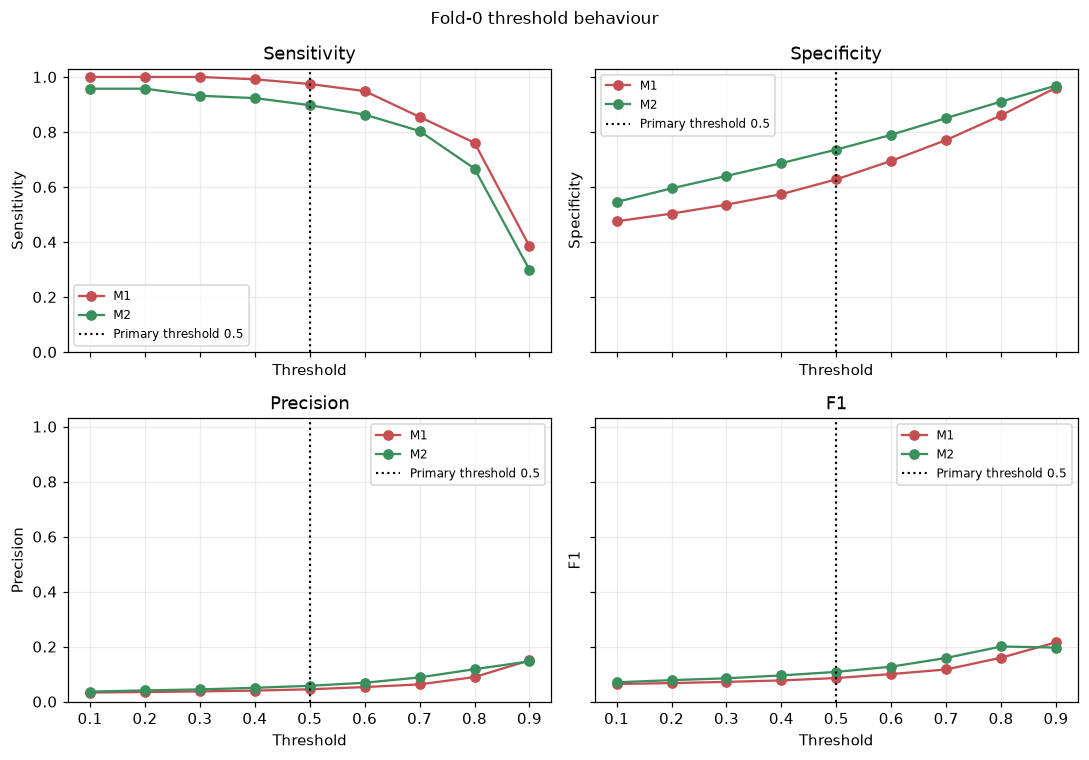

In [9]:
threshold = tables["threshold_summary"].copy()
threshold_metrics = ["sensitivity", "specificity", "precision", "f1"]
threshold_view = pd.concat({
    model_id: threshold.loc[threshold.model.eq(model_id)].set_index("threshold")[threshold_metrics]
    for model_id in ["M1", "M2"]
}, axis=1)
display(threshold_view.round(4))

labels = {
    "sensitivity": "Sensitivity", "specificity": "Specificity",
    "precision": "Precision", "f1": "F1",
}
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for axis, metric in zip(axes.flat, threshold_metrics):
    for model_id in ["M1", "M2"]:
        model_thresholds = threshold.loc[threshold.model.eq(model_id)].sort_values("threshold")
        axis.plot(
            model_thresholds.threshold, model_thresholds[metric], marker="o",
            color=colors[model_id], label=model_id,
        )
    axis.axvline(0.5, color="black", linestyle=":", linewidth=1.4, label="Primary threshold 0.5")
    axis.set(title=labels[metric], xlabel="Threshold", ylabel=labels[metric], ylim=(0, 1.03))
    axis.legend(fontsize=8)
fig.suptitle("Fold-0 threshold behaviour", fontsize=11)
fig.tight_layout()
plt.show()

M1 is generally more sensitive at equal numerical thresholds; M2 is generally more conservative and specific. These threshold-dependent metrics describe a different operating-point view from ROC-AUC and AP.

## 9. Bootstrap uncertainty

Evidence: `bootstrap_summary.csv`, derived from paired patient-level resampling of the fixed validation fold.

In [10]:
bootstrap = tables["bootstrap_summary"][[
    "metric", "observed_m2_minus_m1", "bootstrap_median", "ci_2_5", "ci_97_5",
]].rename(columns={
    "metric": "Metric", "observed_m2_minus_m1": "Observed difference (M2 - M1)",
    "bootstrap_median": "Bootstrap median", "ci_2_5": "2.5 percentile", "ci_97_5": "97.5 percentile",
})
display(bootstrap.round(4))

,Metric,Observed difference (M2 - M1),Bootstrap median,2.5 percentile,97.5 percentile
0,roc_auc_difference,-0.0034,-0.0032,-0.0204,0.0130
1,average_precision_difference,-0.0041,-0.0067,-0.0516,0.0308
2,sensitivity_difference,-0.0769,-0.0753,-0.1395,-0.0261


This is paired patient-level internal bootstrap uncertainty, not external validation. The ROC-AUC and AP difference intervals include zero. The frozen sensitivity-difference interval remains below zero.

## 10. M1/M2 disagreement summary

Evidence: transition and net-error counts in `failure_summary.csv`.

In [11]:
failure = tables["failure_summary"].iloc[0]
disagreement_view = pd.DataFrame({
    "Transition": ["M1 FP to M2 TN", "M1 TP to M2 FN", "M1 TN to M2 FP", "M1 FN to M2 TP"],
    "Count": [
        int(failure.m1_fp_to_m2_tn), int(failure.m1_tp_to_m2_fn),
        int(failure.m1_tn_to_m2_fp), int(failure.m1_fn_to_m2_tp),
    ],
})
net_view = pd.DataFrame({
    "Measure": ["Net false-positive change (M2 - M1)", "Net false-negative change (M2 - M1)"],
    "Value": [int(failure.net_false_positive_change), int(failure.net_false_negative_change)],
})
display(disagreement_view)
display(net_view)

,Transition,Count
0,M1 FP to M2 TN,826
1,M1 TP to M2 FN,9
2,M1 TN to M2 FP,121
3,M1 FN to M2 TP,0


,Measure,Value
0,Net false-positive change (M2 - M1),-705
1,Net false-negative change (M2 - M1),9


M2 removed many M1 false positives but also lost some M1 true positives, explaining the threshold-0.5 trade-off. These transitions do not show that age, sex, or anatomical site individually caused a prediction change.

## 11. Subgroup summary

Evidence: `subgroup_summary.csv`. Sex, age, and anatomical-site views report support alongside performance so sparse-positive groups remain visible.

In [12]:
subgroup = tables["subgroup_summary"].copy()
subgroup_columns = [
    "model", "group_value", "n", "positive_count", "sensitivity", "specificity",
    "roc_auc", "average_precision", "small_positive_count",
]
for group_variable, label in [("sex", "Sex"), ("age", "Age"), ("site", "Anatomical site")]:
    display(Markdown(f"**{label}**"))
    view = subgroup.loc[subgroup.group_variable.eq(group_variable), subgroup_columns].rename(columns={
        "model": "Model", "group_value": "Group", "n": "N", "positive_count": "Positive count",
        "sensitivity": "Sensitivity", "specificity": "Specificity", "roc_auc": "ROC-AUC",
        "average_precision": "AP", "small_positive_count": "Small positive count",
    })
    display(view.round({"Sensitivity": 4, "Specificity": 4, "ROC-AUC": 4, "AP": 4}))

**Sex**

,Model,Group,N,Positive count,Sensitivity,Specificity,ROC-AUC,AP,Small positive count
0,M1,female,3332,46,0.9348,0.6409,0.8868,0.1277,False
1,M1,male,3295,71,1.0000,0.6141,0.9091,0.2128,False
12,M2,female,3332,46,0.8261,0.7383,0.8660,0.1252,False
13,M2,male,3295,71,0.9437,0.7336,0.9163,0.1982,False


**Age**

,Model,Group,N,Positive count,Sensitivity,Specificity,ROC-AUC,AP,Small positive count
2,M1,<40,1432,17,0.9412,0.6247,0.8992,0.0812,False
3,M1,40-59,2964,41,0.9512,0.6534,0.8781,0.1139,False
4,M1,60+,2231,59,1.0000,0.5948,0.9126,0.2586,False
14,M2,<40,1432,17,0.7647,0.7795,0.8767,0.0660,False
15,M2,40-59,2964,41,0.8293,0.7715,0.8706,0.1221,False
16,M2,60+,2231,59,0.9831,0.6598,0.9143,0.2342,False


**Anatomical site**

,Model,Group,N,Positive count,Sensitivity,Specificity,ROC-AUC,AP,Small positive count
5,M1,head/neck,436,16,0.9375,0.4143,0.8167,0.1736,False
6,M1,lower extremity,1745,19,0.9474,0.6460,0.8913,0.1515,False
7,M1,oral/genital,24,3,1.0000,0.1429,1.0000,1.0000,True
8,M1,palms/soles,72,1,1.0000,0.3380,0.9718,0.3333,True
9,M1,torso,3301,54,0.9815,0.6514,0.9110,0.1750,False
10,M1,unknown,102,1,1.0000,0.6535,1.0000,1.0000,True
11,M1,upper extremity,947,23,1.0000,0.6374,0.8908,0.2321,False
17,M2,head/neck,436,16,0.9375,0.4929,0.8656,0.2017,False
18,M2,lower extremity,1745,19,0.9474,0.7451,0.8931,0.1692,False
19,M2,oral/genital,24,3,1.0000,0.6667,0.9524,0.8333,True


Subgroup estimates can be unstable. Groups with very few melanoma cases should not support strong bias claims; this is exploratory internal-validation analysis.

## 12. Failure case summary

Evidence: `failure_summary.csv` plus the frozen manual review record `outputs/analysis/failures/M2_failure_review.csv`.

In [13]:
failure_review_path = ROOT / "outputs" / "analysis" / "failures" / "M2_failure_review.csv"
failure_review = pd.read_csv(failure_review_path)
reviewed_counts = (
    failure_review.groupby("category", sort=False).size().reindex(["FN", "FP", "TP", "TN"])
    .rename("Reviewed cases").reset_index().rename(columns={"category": "Category"})
)

artifact_columns = {
    "hair_visible": "Hair visible",
    "ruler_or_marker_visible": "Ruler or marker visible",
    "dark_border_visible": "Dark border visible",
    "illumination_issue": "Illumination issue",
    "low_contrast": "Low contrast",
    "lesion_near_edge": "Lesion near edge",
    "blur_or_quality_issue": "Blur or quality issue",
}
artifact_rows = []
for column, label in artifact_columns.items():
    counts = failure_review[column].astype(str).str.lower().value_counts()
    artifact_rows.append({
        "Observed feature": label,
        "Yes": int(counts.get("yes", 0)),
        "No": int(counts.get("no", 0)),
        "Unclear": int(counts.get("unclear", 0)),
    })

display(reviewed_counts)
display(pd.DataFrame(artifact_rows))
display(pd.DataFrame({
    "Review integrity measure": ["Selected cases", "Content-unique selected cases"],
    "Count": [int(failure.visual_review_cases), int(failure.content_unique_visual_cases)],
}))

,Category,Reviewed cases
0,FN,6
1,FP,6
2,TP,6
3,TN,6


,Observed feature,Yes,No,Unclear
0,Hair visible,17,7,0
1,Ruler or marker visible,6,18,0
2,Dark border visible,0,24,0
3,Illumination issue,2,22,0
4,Low contrast,12,11,1
5,Lesion near edge,2,21,1
6,Blur or quality issue,2,22,0


,Review integrity measure,Count
0,Selected cases,24
1,Content-unique selected cases,24


These observations are descriptive; no visual artifact was established as a causal failure mechanism. The qualitative selection contains one record per exact-content identity after the duplicate-content issue was corrected.

## 13. Grad-CAM overview

Evidence: the frozen Phase I summary and figure. Grad-CAM is displayed, not recomputed.

,Item,Value
0,Target,Raw melanoma logit
1,Model,M2
2,Metadata during forward,True
3,Interpretation,Image-branch positive-logit attribution condit...
4,Limitation,Does not explain metadata contribution or caus...


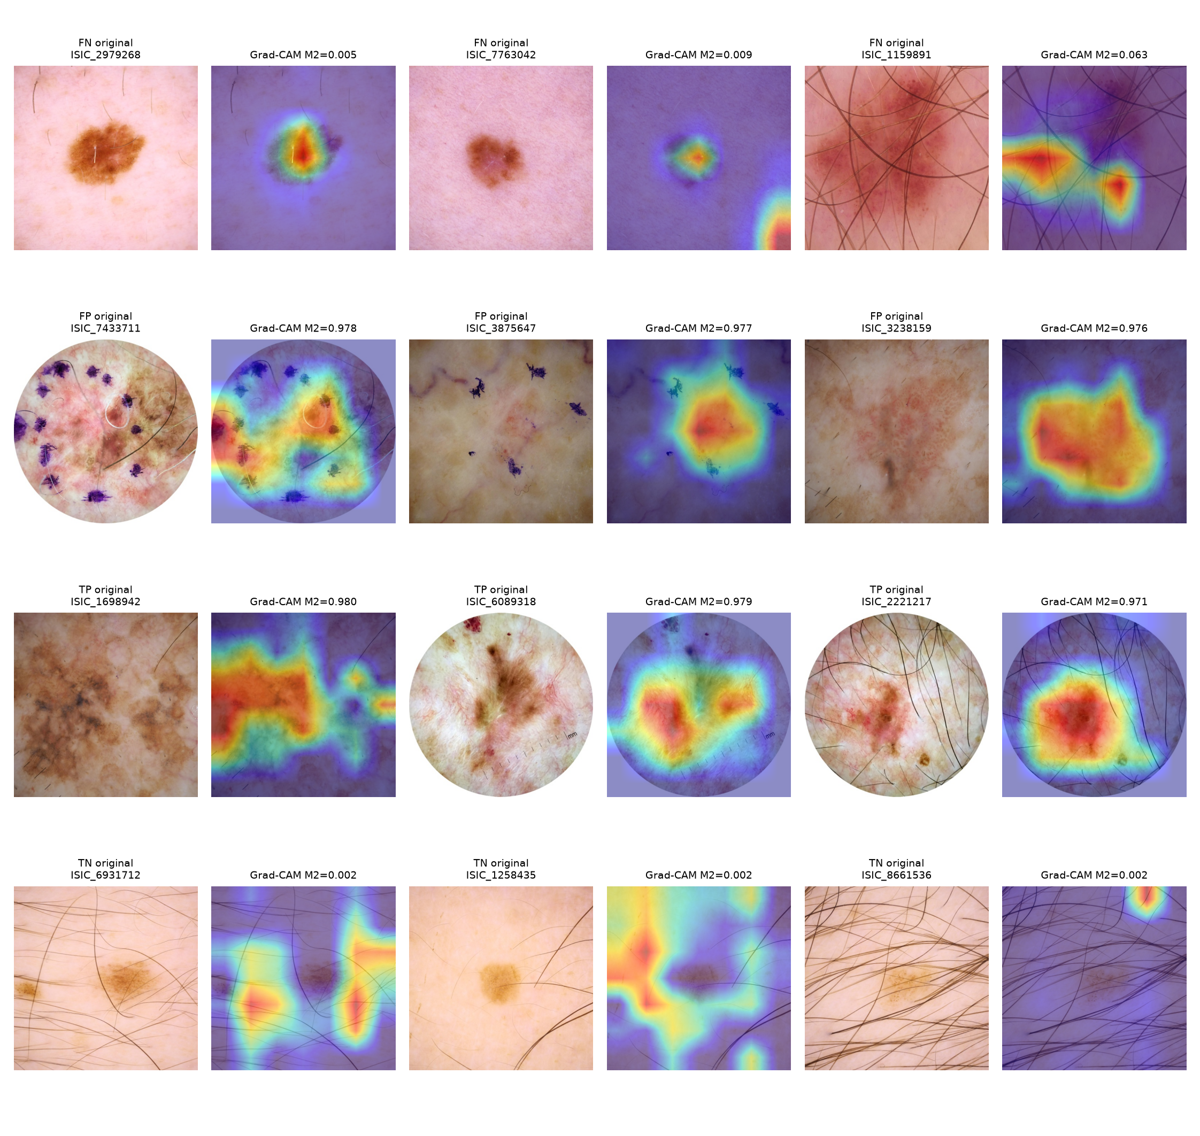

In [14]:
gradcam_summary_path = ROOT / "outputs" / "analysis" / "gradcam" / "M2_gradcam_summary.json"
gradcam_summary = read_json(gradcam_summary_path)
gradcam_view = pd.DataFrame({
    "Item": ["Target", "Model", "Metadata during forward", "Interpretation", "Limitation"],
    "Value": [
        "Raw melanoma logit", "M2", bool(gradcam_summary["metadata_included_during_forward"]),
        "Image-branch positive-logit attribution conditioned on metadata",
        "Does not explain metadata contribution or causal reasoning",
    ],
})
display(gradcam_view)

gradcam_figure = ROOT / gradcam_summary["figure"].replace("\\", "/")
assert gradcam_figure.is_file()
with PILImage.open(gradcam_figure) as source_image:
    gradcam_image = source_image.convert("RGB")
    gradcam_image.thumbnail((1200, 1200))
    display(gradcam_image)

The attribution target is the raw melanoma logit in M2, with metadata supplied during the forward pass. The result is image-branch positive-logit attribution conditioned on metadata; it does not explain the metadata contribution or causal reasoning.

## 14. Data integrity summary

Evidence: `integrity_summary.csv`, `J1B_tables_manifest.json`, and `J1_COMPLETE.json`. The runtime checks below verify current bytes against the frozen SHA-256 records.

In [15]:
integrity_view = pd.DataFrame({
    "Measure": [
        "Patient overlap", "Images hashed", "Unique hashes", "Duplicate groups",
        "Cross-split duplicate groups", "Conflicting-target duplicate groups",
        "Bootstrap multiplicity verified", "Frozen artifact verification",
    ],
    "Value": [
        int(integrity.patient_overlap), int(integrity.images_hashed), int(integrity.unique_hashes),
        int(integrity.duplicate_groups),
        int(integrity.same_patient_cross_split_groups + integrity.different_patient_cross_split_groups),
        int(integrity.conflicting_target_groups), bool(integrity.bootstrap_multiplicity_verified),
        bool(integrity.frozen_artifacts_hash_verified),
    ],
})
display(integrity_view)

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

frozen_checks = []
for record in j1_complete["frozen_hash_verification"]["artifacts"]:
    path = ROOT / record["path"]
    frozen_checks.append(sha256_file(path) == record["sha256"])

table_checks = []
for record in j1_table_manifest["tables"]:
    path = ROOT / record["path"]
    table_checks.append(sha256_file(path) == record["sha256"])

assert all(frozen_checks), "A frozen scientific artifact hash changed"
assert all(table_checks), "A J1 authoritative table hash changed"
display(pd.DataFrame({
    "Runtime verification": ["Frozen scientific artifacts", "J1 authoritative tables"],
    "Files checked": [len(frozen_checks), len(table_checks)],
    "Status": ["PASS", "PASS"],
}))

,Measure,Value
0,Patient overlap,0
1,Images hashed,33126
2,Unique hashes,32693
3,Duplicate groups,433
4,Cross-split duplicate groups,0
5,Conflicting-target duplicate groups,0
6,Bootstrap multiplicity verified,True
7,Frozen artifact verification,True


,Runtime verification,Files checked,Status
0,Frozen scientific artifacts,9,PASS
1,J1 authoritative tables,12,PASS


## 15. Export support

J2A creates no derivative data exports and no publication figures. All displayed tables and plots are notebook outputs computed in memory from frozen evidence.

In [16]:
notebook_exports = []
display(pd.DataFrame({
    "Notebook-support exports": ["None"],
    "Output directory": ["outputs/final/review/notebook_exports/ (not created)"],
}))
assert notebook_exports == []

,Notebook-support exports,Output directory
0,None,outputs/final/review/notebook_exports/ (not cr...
